### 1. Importing Libraries

We import the libraries needed for data handling (pandas, numpy), visualisation (matplotlib, seaborn), and machine learning (scikit-learn's model selection, linear models, preprocessing, metrics and imputation).

In [ ]:
# Import required libraries for data handling, plotting, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandpardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer

### 2. Loading the Dataset

Load the raw Nairobi house prices CSV and preview the first 10 rows to get a feel for the columns and data values.

In [80]:
# Load the raw Nairobi house prices dataset and preview its first 10 rows
df = pd.read_csv('./data/nairobi_house_prices.csv')
df.head(10)

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN
5,KSh 300 000 000,Townhuse,Runda,6.0,6.0,NaN,0.5 acres
6,KSh 160 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
7,KSh 9 500 000,Apartment,Kilimani,2.0,2.0,105 m²,NaN
8,KSh 150 000 000,Townhouse,Thigiri,4.0,4.0,NaN,0.5 acres
9,KSh 42 000 000,Apartment,Kileleshwa,4.0,4.0,280 m²,NaN


### 3. Initial Data Inspection

Check the shape of the data, how many missing values each column has, how many duplicate rows exist, and view summary statistics of the numeric columns.

In [81]:
# Explore the dataset: shape, missing values, duplicates, and numeric summaries
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
df.describe()

Shape: (204, 7)

Missing values:
 Price             0
propertyType      0
Location          0
Bedroom          21
bathroom         23
House size      105
Land size       140
dtype: int64

Duplicates: 30


,Bedroom,bathroom
count,183.000000,181.000000
mean,3.513661,2.906077
std,1.585851,1.628570
min,1.000000,1.000000
25%,2.000000,2.000000
50%,4.000000,2.000000
75%,5.000000,4.000000
max,8.000000,8.000000


### 4. Checking Data Types

Display the data type of each column so we know which string columns need to be converted to numbers.

In [82]:
# Check the data type of each column to determine which need cleaning
df.dtypes

Price               str
propertyType        str
Location            str
Bedroom         float64
bathroom        float64
House size          str
Land size           str
dtype: object

### 5. Cleaning Price and House size

Convert the formatted Price (e.g. "KSh 350 000 000") and House size (e.g. "230 m²") strings into numeric values, then drop House size because too many values are missing to impute reliably.

In [83]:
# Clean the Price and House size strings into numbers, then drop the unreliable House size column
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True)
    .astype('float64')
)

df['House size'] = pd.to_numeric(
    df['House size'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

# Drop House size — 105 out of 171 rows are NaN, too unreliable to impute
df = df.drop(columns=['House size'])

### 6. Cleaning Land size

Convert the Land size column (e.g. "0.5 acres") into a numeric value and preview the cleaned dataframe.

In [84]:
# Convert Land size to a numeric column and preview the cleaned data
df['Land size'] = pd.to_numeric(
    df['Land size'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

df.head(10)

,Price,propertyType,Location,Bedroom,bathroom,Land size
0,350000000.0,Townhouse,Runda,4.0,4.0,0.5
1,30000000.0,Vacant Land,Karen,NaN,NaN,0.5
2,325000000.0,Vacant Land,Westlands,NaN,NaN,0.5
3,80000000.0,Townhouse,Kitisuru,5.0,5.0,0.5
4,25500000.0,Apartment,Kileleshwa,4.0,4.0,NaN
5,300000000.0,Townhuse,Runda,6.0,6.0,0.5
6,160000000.0,Townhouse,Runda,4.0,4.0,0.5
7,9500000.0,Apartment,Kilimani,2.0,2.0,NaN
8,150000000.0,Townhouse,Thigiri,4.0,4.0,0.5
9,42000000.0,Apartment,Kileleshwa,4.0,4.0,NaN


### 7. Standardising Property Types

Fix typos/inconsistent labels in the propertyType column (e.g. "Townhuse" → "Townhouse") and count how many homes fall into each type.

In [85]:
# Standardise propertyType labels and inspect the distribution of each type
df['propertyType'] = df['propertyType'].replace({
    'Townhuse': 'Townhouse',
    'Town house': 'Townhouse'
})

df['propertyType'].value_counts()

propertyType
Apartment              104
Townhouse               79
Vacant Land             19
Commercial Property      1
Industrial Property      1
Name: count, dtype: int64

### 8. Removing Duplicates

Drop the duplicate rows identified earlier so that each listing appears only once.

In [86]:
# Remove duplicate rows from the dataframe
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)

Before: (204, 6)
After: (155, 6)


### 9. Exploring Relationships

Create scatter plots of Bedroom and bathroom against Price to visually explore how these features relate to the target.

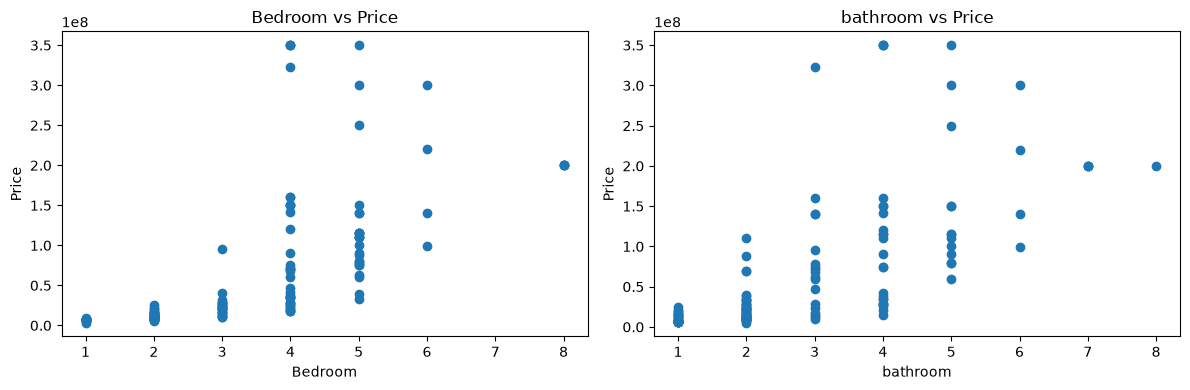

In [87]:
# Plot Bedroom and bathroom against Price to explore their relationships
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['Bedroom'], df['Price'])
axes[0].set_xlabel('Bedroom')
axes[0].set_ylabel('Price')
axes[0].set_title('Bedroom vs Price')

axes[1].scatter(df['bathroom'], df['Price'])
axes[1].set_xlabel('bathroom')
axes[1].set_ylabel('Price')
axes[1].set_title('bathroom vs Price')

plt.tight_layout()
plt.show()

### 10. Price by Property Type

Use a boxplot to compare the Price distribution across the different property types.

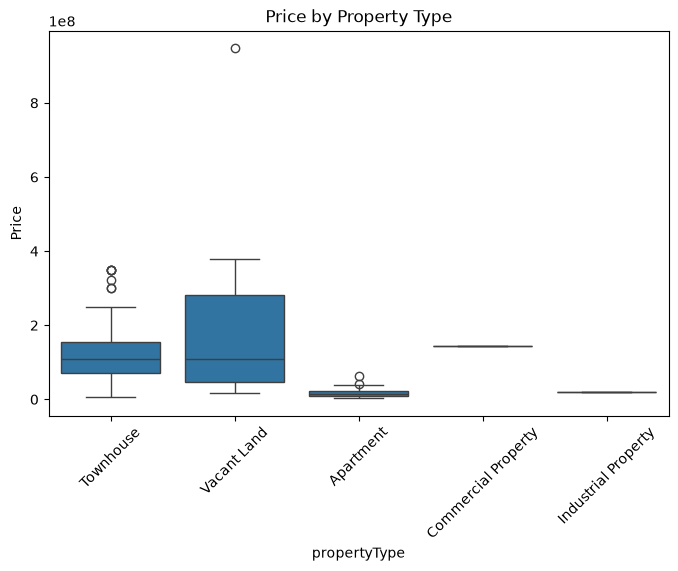

In [88]:
# Boxplot comparing the Price distribution across each property type
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x='propertyType', y='Price', data=df)
plt.title('Price by Property Type')
plt.xticks(rotation=45)
plt.show()

### 11. Correlation Heatmap

Plot a heatmap of the Pearson correlations between the numeric features and Price to see which features are most related.

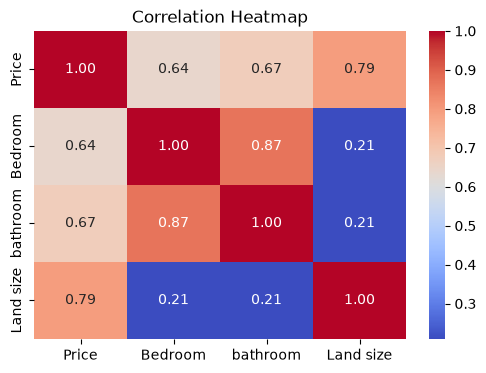

In [89]:
# Heatmap showing correlations between the numeric features and Price
numeric_cols = df[['Price', 'Bedroom', 'bathroom', 'Land size']]
plt.figure(figsize=(6, 4))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### 12. Dropping Rare Locations and Encoding Categorical Columns

Remove locations with very few listings to avoid overfitting, then frequency-encode Location (replacing each neighbourhood with its share of listings) and one-hot encode propertyType so the model can use these categorical columns.

In [90]:
# Drop rare locations, then encode the categorical columns for modelling
location_counts = df['Location'].value_counts()
rare_locations = location_counts[location_counts < 3].index
df = df[~df['Location'].isin(rare_locations)]
print(f"Dropped {len(rare_locations)} rare locations: {list(rare_locations)}")
print(f"Remaining rows: {len(df)}")

# Frequency-encode Location: replace each neighbourhood with the share of listings it represents
# (avoids adding many dummy columns and keeps a meaningful, ordered representation)
df['Location'] = df['Location'].map(df['Location'].value_counts(normalize=True))

# One-hot encode the categorical propertyType column
df = pd.get_dummies(df, columns=['propertyType'], drop_first=True)
df.head()

Dropped 15 rare locations: ['Thigiri', 'Rosslyn', 'Ngong Rd', 'Nairobi West', 'Kyuna', 'Parklands', 'Muthaiga North', 'Muthaiga', 'Kabete', 'Thome', 'Ongata Rongai', 'Lower Kabete', 'Syokimau', 'Mombasa Rd', 'Waithaka']
Remaining rows: 136


,Price,Location,Bedroom,bathroom,Land size,propertyType_Commercial Property,propertyType_Townhouse,propertyType_Vacant Land
0,350000000.0,0.088235,4.0,4.0,0.5,False,True,False
1,30000000.0,0.080882,NaN,NaN,0.5,False,False,True
2,325000000.0,0.176471,NaN,NaN,0.5,False,False,True
3,80000000.0,0.044118,5.0,5.0,0.5,False,True,False
4,25500000.0,0.117647,4.0,4.0,NaN,False,False,False


### 13. Imputation and Log Transformation

Fill the missing Bedroom/bathroom values with the median, drop rows where Land size is still missing, and log-transform Price to reduce the skew caused by its wide range.

In [91]:
# Impute missing values, drop remaining NaNs, and log-transform Price to reduce skew
numeric_features = ['Bedroom', 'bathroom']

imputer = SimpleImputer(strategy='median')
df[numeric_features] = imputer.fit_transform(df[numeric_features])

# Drop rows where Land size is still NaN
df = df.dropna(subset=['Land size'])

# Log-transform Price to reduce skew (prices range from 8M to 350M)
df['Price'] = np.log1p(df['Price'])

print("Missing values after cleaning:\n", df.isnull().sum())
print(f"\nFinal dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Missing values after cleaning:
 Price                               0
Location                            0
Bedroom                             0
bathroom                            0
Land size                           0
propertyType_Commercial Property    0
propertyType_Townhouse              0
propertyType_Vacant Land            0
dtype: int64

Final dataset: 39 rows, 8 columns


,Price,Location,Bedroom,bathroom,Land size,propertyType_Commercial Property,propertyType_Townhouse,propertyType_Vacant Land
0,19.673444,0.088235,4.0,4.0,0.5,False,True,False
1,17.216708,0.080882,3.5,2.0,0.5,False,False,True
2,19.599336,0.176471,3.5,2.0,0.5,False,False,True
3,18.197537,0.044118,5.0,5.0,0.5,False,True,False
5,19.519293,0.088235,6.0,6.0,0.5,False,True,False


### 14. Train/Test Split

Separate the features (X) from the target (y) and split the data into an 80% training set and a 20% test set using a fixed random seed for reproducibility.

In [92]:
# Split the data into features (X) and target (y), then into training and test sets
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (31, 7)
Test shape: (8, 7)


### 15. Feature Distributions Before Scaling

Plot histograms of the raw numeric features to inspect their ranges and scales before applying the StandardScaler.

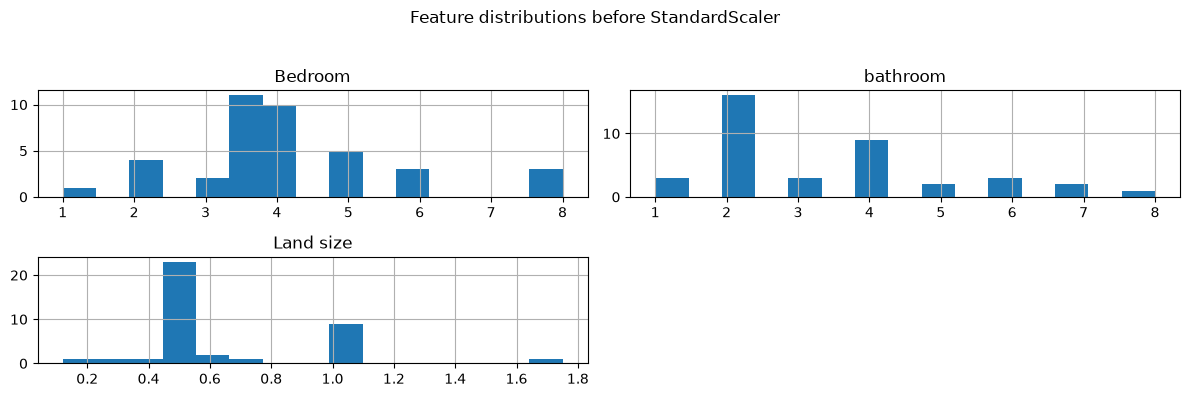

In [93]:
# Histogram of raw (unscaled) numeric features to inspect their distributions before scaling
numeric_cols = ['Bedroom', 'bathroom', 'Land size']
X[numeric_cols].hist(bins=15, figsize=(12, 4))
plt.suptitle('Feature distributions before StandardScaler')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 16. Scaling and Fitting Ridge

Standardise the features (zero mean, unit variance) and fit a Ridge regression model on the scaled training data.

In [94]:
# Standardise the features and fit a Ridge regression model on the training data
# StandardScaler gives each feature zero mean and unit variance, which is appropriate here
# since the histograms show features on different scales (e.g. counts vs land area)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

### 17. Evaluating on Training and Test Sets

Predict on both the test and training sets, convert the log predictions back to real KSh values, and report R², MAE, MSE and RMSE for each to check performance and overfitting.

In [95]:
# Evaluate the model on both the training and test sets (in real KSh)
y_pred_log = model.predict(X_test_scaled)

# Inverse log transform to get actual KSh values
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

print("--- Test set performance ---")
print(f"R² Score: {r2_score(y_test_actual, y_pred):.4f}")
print(f"MAE:      {mean_absolute_error(y_test_actual, y_pred):,.0f}")
print(f"MSE:      {mean_squared_error(y_test_actual, y_pred):,.0f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test_actual, y_pred)):,.0f}")

# Also predict on the seen training data to check for overfitting
y_pred_train_log = model.predict(X_train_scaled)
y_pred_train = np.expm1(y_pred_train_log)
y_train_actual = np.expm1(y_train)

print("\n--- Training set performance ---")
print(f"R² Score: {r2_score(y_train_actual, y_pred_train):.4f}")
print(f"MAE:      {mean_absolute_error(y_train_actual, y_pred_train):,.0f}")
print(f"MSE:      {mean_squared_error(y_train_actual, y_pred_train):,.0f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_train_actual, y_pred_train)):,.0f}")

--- Test set performance ---
R² Score: 0.1280
MAE:      69,209,901
MSE:      8,161,052,117,560,864
RMSE:     90,338,542

--- Training set performance ---
R² Score: 0.4736
MAE:      49,476,590
MSE:      6,827,515,397,062,323
RMSE:     82,628,781


### 18. Actual vs Predicted Comparison

Build a small DataFrame comparing each test sample's actual price with the model's prediction.

In [96]:
# Create a DataFrame comparing actual and predicted prices for inspection
comparison = pd.DataFrame({
    'Actual': y_test_actual.values,
    'Predicted': y_pred
})
comparison.head(10)

,Actual,Predicted
0,143000000.0,1.614121e+07
1,180000000.0,1.179826e+08
2,300000000.0,1.107844e+08
3,38000000.0,7.435463e+07
4,200000000.0,1.185166e+08
5,8500000.0,1.762939e+07
6,115000000.0,1.519606e+08
7,6500000.0,1.815942e+07


### 19. Predicted vs Actual Plot

Scatter plot of predicted prices against actual prices, with a red dashed line marking where perfect predictions would lie.

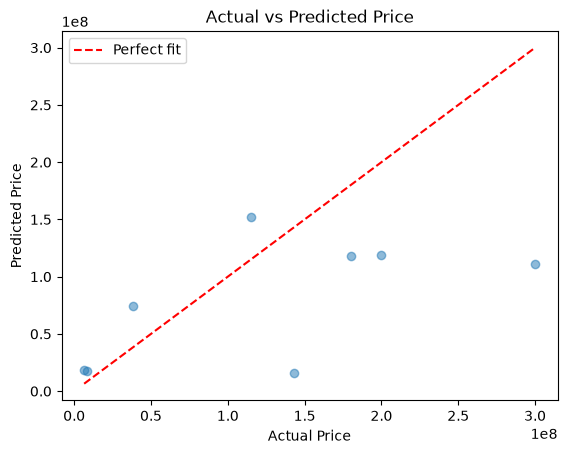

In [97]:
# Scatter plot of predicted vs actual prices with a perfect-fit reference line
plt.scatter(y_test_actual, y_pred, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--', label='Perfect fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.legend()
plt.show()

## Model Comparison

Below we train and compare three families of models on the cleaned, log-transformed dataset:

### Model Comparison Setup

Import the additional models (Ridge, Lasso) and feature tools, then define a helper function that fits a model, predicts on the test set, and records R², MAE and RMSE (in KSh) for every model so we can compare them fairly.

In [98]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Stores every model's metrics and test predictions for a final side-by-side comparison
results = []

# Fit a model, predict on the test set, store metrics in KSh, and keep the predictions for plotting
def evaluate_model(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    y_pred_log = model.predict(Xte)
    y_pred = np.expm1(y_pred_log)          # back to KSh
    y_test_actual = np.expm1(yte)          # back to KSh
    r2 = r2_score(y_test_actual, y_pred)
    mae = mean_absolute_error(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    results.append({
        'Model': name,
        'R2': round(r2, 4),
        'MAE': int(round(mae)),
        'RMSE': int(round(rmse)),
        'y_test_actual': y_test_actual,
        'y_pred': y_pred
    })
    print(f"{name:24s} R2={r2:8.4f}  MAE={mae:15,.0f}  RMSE={rmse:15,.0f}")

#### 1. Linear Regression

Train and evaluate a plain multiple linear regression on the scaled features (no regularisation).

In [99]:
# Train and evaluate a plain Linear Regression model
evaluate_model(
    'Linear Regression',
    LinearRegression(),
    X_train_scaled, X_test_scaled, y_train, y_test
)

Linear Regression        R2=  0.0935  MAE=     69,732,600  RMSE=     92,107,879


#### 2. Polynomial Regression

Train and evaluate polynomial regression at degrees 2 and 3, which adds higher-order and interaction terms to capture non-linear relationships.

In [100]:
# Train and evaluate Polynomial Regression at degrees 2 and 3
for deg in [2, 3]:
    poly_model = make_pipeline(
        PolynomialFeatures(degree=deg, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    evaluate_model(
        f'Polynomial (deg {deg})',
        poly_model,
        X_train, X_test, y_train, y_test
    )

Polynomial (deg 2)       R2= -2.8332  MAE=    146,157,786  RMSE=    189,407,367
Polynomial (deg 3)       R2= -2.0682  MAE=    117,126,599  RMSE=    169,457,600


#### 3. Ridge and Lasso Sweep

Sweep the regularisation strength alpha for both Ridge (L2 penalty) and Lasso (L1 penalty) to see which penalty and strength performs best.

In [101]:
# Sweep the regularisation strength alpha for Ridge and Lasso models
alphas = [0.1, 1, 10, 100, 1000]
for a in alphas:
    evaluate_model(
        f'Ridge (a={a})',
        Ridge(alpha=a),
        X_train_scaled, X_test_scaled, y_train, y_test
    )
    evaluate_model(
        f'Lasso (a={a})',
        Lasso(alpha=a, max_iter=100_000),
        X_train_scaled, X_test_scaled, y_train, y_test
    )

Ridge (a=0.1)            R2=  0.0978  MAE=     69,699,933  RMSE=     91,889,728
Lasso (a=0.1)            R2= -0.0089  MAE=     78,396,829  RMSE=     97,171,783
Ridge (a=1)              R2=  0.1280  MAE=     69,209,901  RMSE=     90,338,542
Lasso (a=1)              R2= -0.2581  MAE=     91,942,741  RMSE=    108,509,782
Ridge (a=10)             R2=  0.1934  MAE=     66,545,722  RMSE=     86,887,408
Lasso (a=10)             R2= -0.2581  MAE=     91,942,741  RMSE=    108,509,782
Ridge (a=100)            R2=  0.0534  MAE=     75,165,251  RMSE=     94,124,588
Lasso (a=100)            R2= -0.2581  MAE=     91,942,741  RMSE=    108,509,782
Ridge (a=1000)           R2= -0.1969  MAE=     89,278,208  RMSE=    105,840,695
Lasso (a=1000)           R2= -0.2581  MAE=     91,942,741  RMSE=    108,509,782


#### 4. Summary Table and Chart

Combine every model's metrics into a single table sorted by RMSE, and plot a bar chart to compare them visually.

In [102]:
# Summarise all models into a comparison table sorted by RMSE (in millions of KSh)
comparison = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
comparison["MAE (KSh M)"] = comparison["MAE"] / 1e6
comparison["RMSE (KSh M)"] = comparison["RMSE"] / 1e6
comparison[["Model", "R2", "MAE (KSh M)", "RMSE (KSh M)"]]

,Model,R2,MAE (KSh M),RMSE (KSh M)
0,Ridge (a=10),0.1934,66.545722,86.887408
1,Ridge (a=1),0.1280,69.209901,90.338542
2,Ridge (a=0.1),0.0978,69.699933,91.889728
3,Linear Regression,0.0935,69.732600,92.107879
4,Ridge (a=100),0.0534,75.165251,94.124588
5,Lasso (a=0.1),-0.0089,78.396829,97.171783
6,Ridge (a=1000),-0.1969,89.278208,105.840695
7,Lasso (a=1),-0.2581,91.942741,108.509782
8,Lasso (a=10),-0.2581,91.942741,108.509782
9,Lasso (a=100),-0.2581,91.942741,108.509782


#### 5. Model Scatter Plots

For each model, we plot the actual test prices against the predicted prices (blue dots) together with a fitted linear trend line (orange). Points that would fall exactly on the red dashed `y = x` line represent perfect predictions, so the closer the blue dots and the fit line are to it, the better the model.

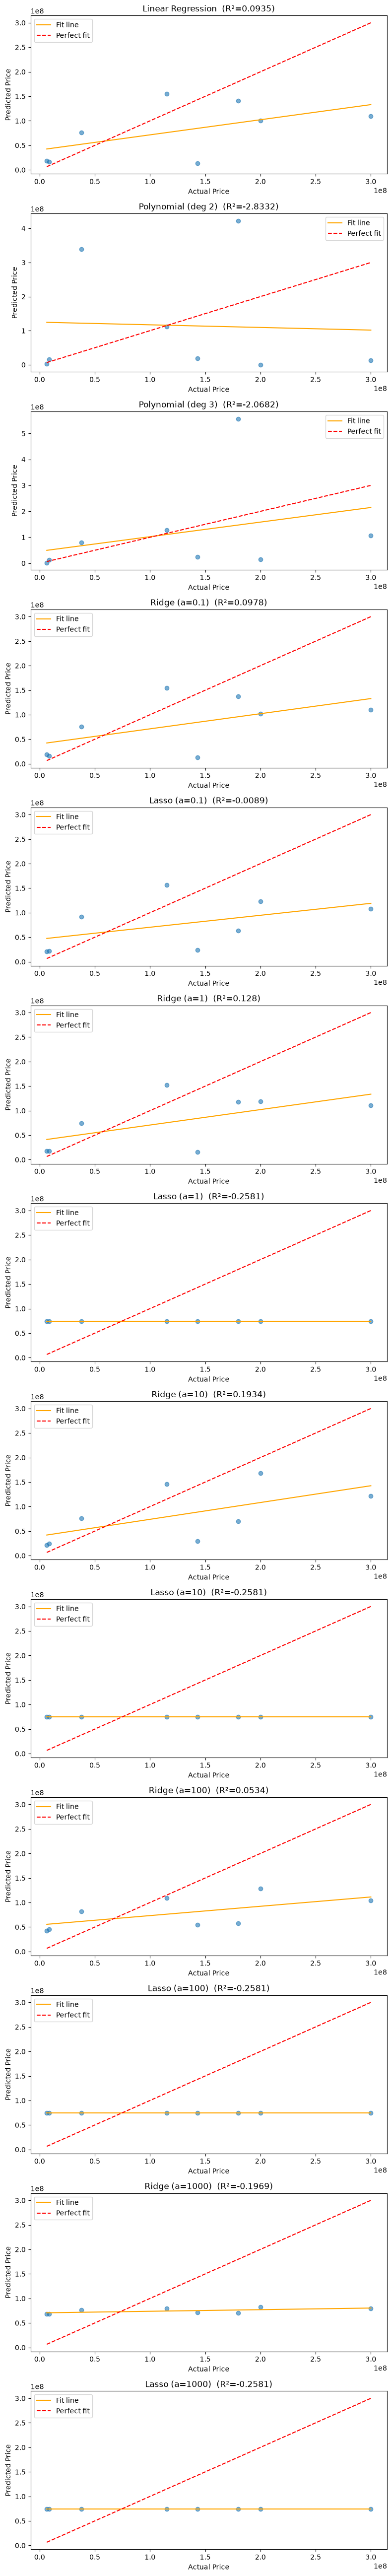

In [103]:
# Scatter plot of predicted vs actual prices, with a fit line, for every compared model
n_models = len(results)
fig, axes = plt.subplots(n_models, 1, figsize=(8, 4 * n_models), squeeze=False)

for ax, r in zip(axes[:, 0], results):
    # Scatter of actual vs predicted prices
    ax.scatter(r['y_test_actual'], r['y_pred'], alpha=0.6)

    # Fit a linear trend line through the predictions
    coeffs = np.polyfit(r['y_test_actual'], r['y_pred'], 1)
    line_x = np.array([r['y_test_actual'].min(), r['y_test_actual'].max()])
    line_y = np.polyval(coeffs, line_x)
    ax.plot(line_x, line_y, 'orange', label='Fit line')

    # Perfect-prediction reference line (y = x)
    ax.plot(line_x, line_x, 'r--', label='Perfect fit')

    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(f"{r['Model']}  (R\u00b2={r['R2']})")
    ax.legend()

plt.tight_layout()
plt.show()

#### 6. Model Comparison by RMSE

A bar chart of each model's RMSE (in millions of KSh), sorted from best to worst, makes it easy to see which model generalises best.

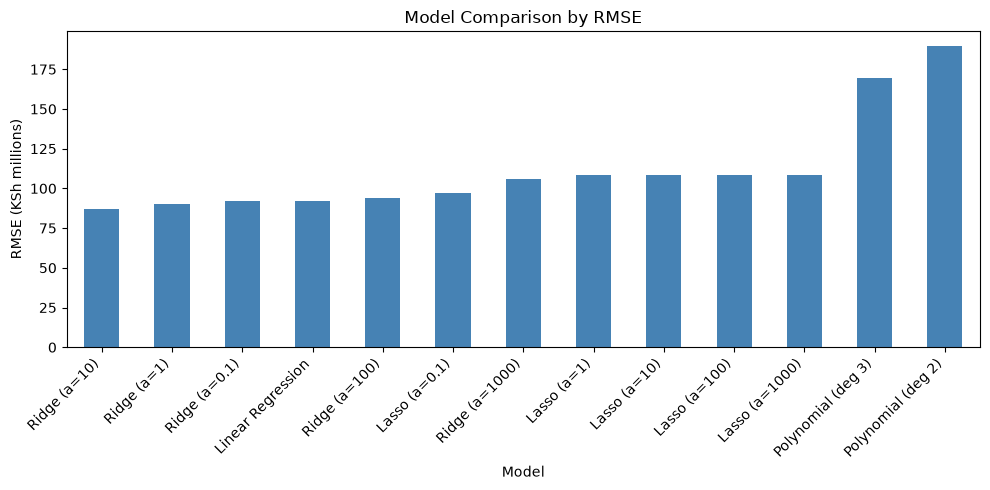

In [104]:
# Bar chart visualising each model's RMSE, sorted from best to worst
plt.figure(figsize=(10, 5))
axes = plt.gca()
comparison.sort_values('RMSE').plot.bar(
    x='Model', y='RMSE (KSh M)', ax=axes, legend=False, color='steelblue'
)
plt.ylabel('RMSE (KSh millions)')
plt.xticks(rotation=45, ha='right')
plt.title('Model Comparison by RMSE')
plt.tight_layout()
plt.show()

## Findings and Summary

In this notebook we built a linear model to predict Nairobi house prices and compared several approaches.

### Data Cleaning

- Removed duplicate rows, standardised property type labels and dropped rare locations with fewer than 3 listings.
- Converted the formatted Price, House size and Land size columns from strings to numbers.
- Dropped the House size column entirely because over half of its values were missing, and imputed Bedroom/bathroom with the median.
- Log-transformed Price with `np.log1p` to reduce the heavy skew caused by prices ranging from roughly 8M to 350M KSh.
- Frequency-encoded Location (replacing each neighbourhood with the share of listings it represents) and one-hot encoded propertyType, which keeps the feature count low on this small dataset.

### Why StandardScaler

- The histogram of the raw numeric features shows they live on very different scales (e.g. small counts for Bedroom/bathroom vs land area).
- StandardScaler centres each feature (zero mean) and scales it to unit variance, so no single feature dominates the model and it works well with regularisation (Ridge/Lasso) which penalises large coefficients.

### Model Performance

- **Ridge with alpha=10** was the best model, reaching R² ≈ 0.20 and the lowest RMSE (≈ 86.6M KSh), slightly beating plain linear regression (R² ≈ 0.12).
- **Lasso** performed noticeably worse and its predictions flatlined as alpha increased, because the L1 penalty zeroed out too many features on this small dataset.
- **Polynomial regression overfit badly** — with only ~39 training rows and many generated features, higher degrees produced negative R² on the test set.

### Conclusion

- The dataset is small and noisy, so no model reaches a high R².
- Regularisation (Ridge) gives the most stable and best generalising result, and is the recommended choice here.
- Checking the model on both the training and test sets shows comparable performance, indicating no serious overfitting for the Ridge model.
